# Loading Sample df

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import sys
from pathlib import Path
import logging

### Loading Config

In [2]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
with open(CONFIG_PATH, "r") as f:
    config  = yaml.safe_load(f)

PROCESSED_PATH = PROJECT_ROOT / config["data"]["processed_path"]
VELOCITY_MIN_PERIODS = config["features"]["velocity_min_periods"]
SPEND_MIN_PERIODS = config["features"]["spend_min_periods"]

print("Config loaded")
print(f"Processed path : {PROCESSED_PATH}")

Config loaded
Processed path : C:\Users\HP\Documents\Fraud_Detection_System\data\processed\transactions_clean.parquet


### Loading logger

In [3]:
# Loading logger
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "feature_notebook.log"

logging.basicConfig(
    level= logging.INFO,
    format= "%(asctime)s | %(levelname)s | %(message)s",
    datefmt= "%d-%m-%Y %H:%M:%S",
    handlers= [
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

logger.info("Jupyter Notebook Sample of 200 Users")

13-06-2026 00:58:33 | INFO | Jupyter Notebook Sample of 200 Users


### Loading sample with 200 user's txn details

In [4]:
df_full = pd.read_parquet(PROCESSED_PATH, columns=[
    'user_id', 'card', 'timestamp', 'amount', 'is_refund',
    'mcc', 'use_chip', 'merchant_name', 'merchant_city', 
    'merchant_state', 'is_fraud', 'is_high_value', 'error_bad_cvv', 
    'error_bad_expiration', 'error_bad_card', 'error_bad_pin'
])

df = df_full[df_full["user_id"] < 200].copy()  # user 0 to user 199
del df_full

print(f"Sample shape : {df.shape}")
print(f"Users : {df['user_id'].nunique()}")
print(f"Cards : {df['card'].nunique()}")
print(f"Timestamp range : {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Sample Fraud Rate : {df['is_fraud'].mean():.4f}")
print(f"Columns in df : {list(df.columns)}")

Sample shape : (2418341, 16)
Users : 200
Cards : 9
Timestamp range : 1995-06-18 19:25:00 to 2020-02-28 23:49:00
Sample Fraud Rate : 0.0011
Columns in df : ['user_id', 'card', 'timestamp', 'amount', 'is_refund', 'mcc', 'use_chip', 'merchant_name', 'merchant_city', 'merchant_state', 'is_fraud', 'is_high_value', 'error_bad_cvv', 'error_bad_expiration', 'error_bad_card', 'error_bad_pin']


In [5]:
sample = df[(df['user_id'] == 0) & (df['card'] == 0)]

print(f"Verifying sort order for user 0, card 0 : ")
print(f"Total rows : {len(sample)}")
print(f"Sorted correctly : {sample['timestamp'].is_monotonic_increasing} \n")
print(sample['timestamp'].head(5).values)

Verifying sort order for user 0, card 0 : 
Total rows : 5011
Sorted correctly : True 

['2002-09-01T06:21:00.000000000' '2002-09-01T06:42:00.000000000'
 '2002-09-02T06:22:00.000000000' '2002-09-02T17:45:00.000000000'
 '2002-09-03T06:23:00.000000000']


# Feature Engineering

## Temporal Features

In [6]:
from src.features.feature_utils import compute_temp_features

df = compute_temp_features(df)

print("Temporal Features :")
print(df[['timestamp', 'day_of_week', 'is_weekend', 
          'is_night', 'hour_sin', 'hour_cos']].head(10))

print(f"\nis_weekend count : {df['is_weekend'].value_counts()}")
print(f"\nis_night count : {df['is_night'].value_counts()}")
print(f"\nhour_sin range : {df['hour_sin'].min()} to {df['hour_sin'].max()}")
print(f"hour_cos range : {df['hour_cos'].min()} to {df['hour_cos'].max()}")

Temporal Features :
            timestamp  day_of_week  is_weekend  is_night      hour_sin  \
0 2010-09-25 16:20:00            5           1         0 -8.660254e-01   
1 2010-09-25 21:55:00            5           1         0 -7.071068e-01   
2 2010-09-26 12:53:00            6           1         0  1.224647e-16   
3 2010-09-27 08:07:00            0           0         0  8.660254e-01   
4 2010-09-27 08:32:00            0           0         0  8.660254e-01   
5 2010-09-27 16:36:00            0           0         0 -8.660254e-01   
6 2010-09-28 07:32:00            1           0         0  9.659258e-01   
7 2010-09-29 08:55:00            2           0         0  8.660254e-01   
8 2010-09-30 09:52:00            3           0         0  7.071068e-01   
9 2010-09-30 11:57:00            3           0         0  2.588190e-01   

   hour_cos  
0 -0.500000  
1  0.707107  
2 -1.000000  
3 -0.500000  
4 -0.500000  
5 -0.500000  
6 -0.258819  
7 -0.500000  
8 -0.707107  
9 -0.965926  

is_weekend

### Time Since Last Transaction

In [7]:
from src.features.feature_utils import compute_time_since_last_txn

df['minutes_since_last_txn'] = compute_time_since_last_txn(df)

print("Time since last transaction in minutes :")
print(df[['user_id', 'card', 'timestamp', 'minutes_since_last_txn']].head(15))

# Checking for 1st transaction per user per card
first_txn = df.groupby(['user_id', 'card']).head(1)
print(f"\nminutes_since_last_txn value for first transactions : \n{first_txn['minutes_since_last_txn'].value_counts()}")
print(f"\nAll first transactions are -1 : {(first_txn['minutes_since_last_txn'] == -1).all()}")

# Distribution of other transactions
other_txn = df[df['minutes_since_last_txn'] != -1]['minutes_since_last_txn']
print(f"\nDistribution of other transactions in minutes : \n{other_txn.describe()}")

Time since last transaction in minutes :
    user_id  card           timestamp  minutes_since_last_txn
0        47     2 2010-09-25 16:20:00                   270.0
1        47     2 2010-09-25 21:55:00                   335.0
2        47     2 2010-09-26 12:53:00                   898.0
3        47     2 2010-09-27 08:07:00                  1154.0
4        47     2 2010-09-27 08:32:00                    25.0
5        47     2 2010-09-27 16:36:00                   484.0
6        47     2 2010-09-28 07:32:00                   896.0
7        47     2 2010-09-29 08:55:00                  1523.0
8        47     2 2010-09-30 09:52:00                  1497.0
9        47     2 2010-09-30 11:57:00                   125.0
10       47     2 2010-09-30 16:25:00                   268.0
11       47     2 2010-09-30 21:52:00                   327.0
12       47     2 2010-10-01 07:54:00                   602.0
13       47     2 2010-10-01 07:58:00                     4.0
14       47     2 2010-10-01 

## MCC Encoding

In [8]:
from src.features.feature_utils import compute_mcc_encoding, apply_mcc_encoding

# Computing only for Training Data
V1_TRAIN_END = config["splits"]["v1_train_end"]

train_mask = df['timestamp'].dt.year <= V1_TRAIN_END
train_df = df[train_mask]

print(f"Number of training rows (upto {V1_TRAIN_END}) : {len(train_df)}")
print(f"Training Fraud Rate : {train_df['is_fraud'].mean():.4f}\n")

mcc_freq = compute_mcc_encoding(train_df)
df['mcc_frequency'] = apply_mcc_encoding(df, mcc_freq)  # Saving temporarily

print(f"\nMCC frequency : \n{df[['mcc', 'mcc_frequency']].head(10)}")

top_5 = sorted(mcc_freq.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n5 most frequent MCC codes : ")
for mcc, freq in top_5:
    print(f"MCC {mcc} : {freq:.4f}")

print(f"\nUnknown MCC in training dataset : {(df.loc[train_mask, 'mcc_frequency'] == 0).sum()}")
print(f"Unknown MCC in full dataset : {(df['mcc_frequency'] == 0).sum()}")

13-06-2026 00:58:43 | INFO | MCC Encoding computed : 109 unique MCC Codes
13-06-2026 00:58:43 | INFO | MCC Encoding saved to path : C:\Users\HP\Documents\Fraud_Detection_System\models\artifacts\mcc_encoding.pkl


Number of training rows (upto 2010) : 932669
Training Fraud Rate : 0.0013


MCC frequency : 
    mcc  mcc_frequency
0  4829       0.043365
1  7538       0.034907
2  5045       0.000193
3  5812       0.075380
4  4121       0.038910
5  5300       0.046721
6  4784       0.053691
7  4121       0.038910
8  5942       0.018950
9  4121       0.038910

5 most frequent MCC codes : 
MCC 5411 : 0.1176
MCC 5499 : 0.1043
MCC 5541 : 0.0948
MCC 5812 : 0.0754
MCC 5912 : 0.0597

Unknown MCC in training dataset : 0
Unknown MCC in full dataset : 0


## Card Rolling Features

### Velocity Features

In [9]:
from src.features.feature_utils import compute_velocity_features, compute_spend_features
NOTEBOOK_VELOCITY_WINDOWS_MIN = config["features"]["notebook_velocity_windows_min"]
BASELINE_WINDOW_DAYS = config["features"]["baseline_window_days"]

df = df.sort_values(["user_id", "card", "timestamp"]).reset_index(drop=True)
group_cards = df.groupby(["user_id", "card"], sort=False)

# Transaction count for each velocity window
for window in NOTEBOOK_VELOCITY_WINDOWS_MIN:
    col_name = f"card_txn_count_{window}min"
    df[col_name] = (
        group_cards[['timestamp', "is_refund"]]
        .apply(lambda x: compute_velocity_features(x, window_min=window))
        .reset_index(level=[0, 1], drop=True)
        .astype("float32")
    )
    print(f"Column computed : {col_name}")

# Transaction count for each baseline window
for window in BASELINE_WINDOW_DAYS:
    col_name = f"card_txn_count_{window}d"
    df[col_name] = (
        group_cards[['timestamp', "is_refund"]]
        .apply(lambda x: compute_velocity_features(x, window_min=window * 1440))
        .reset_index(level=[0, 1], drop=True)
        .astype("float32")
    )
    print(f"Column computed : {col_name}")

Column computed : card_txn_count_5min
Column computed : card_txn_count_60min
Column computed : card_txn_count_1440min
Column computed : card_txn_count_30d
Column computed : card_txn_count_365d


### Spend features

In [10]:
for window in BASELINE_WINDOW_DAYS:
    card_spend_features = (
        group_cards
        .apply(lambda x: compute_spend_features(x, 'card', window))
        .reset_index(level=[0, 1], drop=True)
        .astype("float32")
    )

    df[card_spend_features.columns] = card_spend_features
    print(f"Computed Card Spend Features for : {window}d")

C:\Users\HP\AppData\Local\Temp\ipykernel_1884\2581149495.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_spend_features(x, 'card', window))


Computed Card Spend Features for : 30d
Computed Card Spend Features for : 365d


C:\Users\HP\AppData\Local\Temp\ipykernel_1884\2581149495.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_spend_features(x, 'card', window))


In [11]:
print("Card-level Rolling Features :")
card_features = ["user_id", "card", "timestamp", "amount", "card_txn_count_5min", 
                "card_txn_count_60min", "card_txn_count_1440min", "card_txn_count_30d", 
                "card_txn_count_365d", "card_spend_mean_30d", "card_spend_std_30d", 
                "card_spend_mean_365d", "card_spend_std_365d"]
print(df[card_features].head(10))

Card-level Rolling Features :
   user_id  card           timestamp  amount  card_txn_count_5min  \
0        0     0 2002-09-01 06:21:00  134.09                  0.0   
1        0     0 2002-09-01 06:42:00   38.48                  1.0   
2        0     0 2002-09-02 06:22:00  120.34                  1.0   
3        0     0 2002-09-02 17:45:00  128.95                  1.0   
4        0     0 2002-09-03 06:23:00  104.71                  1.0   
5        0     0 2002-09-03 13:53:00   86.19                  1.0   
6        0     0 2002-09-04 05:51:00   93.84                  1.0   
7        0     0 2002-09-04 06:09:00  123.50                  1.0   
8        0     0 2002-09-05 06:14:00   61.72                  1.0   
9        0     0 2002-09-05 09:35:00   57.10                  1.0   

   card_txn_count_60min  card_txn_count_1440min  card_txn_count_30d  \
0                   0.0                     0.0                 0.0   
1                   1.0                     1.0                 1.0 

### Verifications

In [12]:
# First transactions mean values (should be NaN)
first_txns = df.groupby(["user_id", "card"]).head(1)
nan_count = first_txns["card_spend_mean_30d"].isna().sum()

print(f"Number of first transactions per user per card: {len(first_txns)}")
print(f"Number of first transactions with NaN card_spend_mean_30d: {nan_count}")

Number of first transactions per user per card: 598
Number of first transactions with NaN card_spend_mean_30d: 598


In [13]:
# Missing Percentage
print(df[card_features].isna().mean().mul(100).round(2))

# Velocity Columns
velocity_card_cols = ['card_txn_count_5min', 'card_txn_count_60min', 'card_txn_count_1440min', 
                      'card_txn_count_30d', 'card_txn_count_365d']

print(df[velocity_card_cols].describe())

# Spend Columns
spend_card_cols = ['card_spend_mean_30d', 'card_spend_std_30d', 'card_spend_mean_365d', 
                'card_spend_std_365d']

print(df[spend_card_cols].describe())

user_id                   0.00
card                      0.00
timestamp                 0.00
amount                    0.00
card_txn_count_5min       0.00
card_txn_count_60min      0.00
card_txn_count_1440min    0.00
card_txn_count_30d        0.00
card_txn_count_365d       0.00
card_spend_mean_30d       0.10
card_spend_std_30d        0.10
card_spend_mean_365d      0.08
card_spend_std_365d       0.08
dtype: float64
       card_txn_count_5min  card_txn_count_60min  card_txn_count_1440min  \
count         2.418341e+06          2.418341e+06            2.418341e+06   
mean          9.931139e-01          1.205661e+00            3.069799e+00   
std           2.498114e-01          5.434110e-01            1.915442e+00   
min           0.000000e+00          0.000000e+00            0.000000e+00   
25%           1.000000e+00          1.000000e+00            2.000000e+00   
50%           1.000000e+00          1.000000e+00            3.000000e+00   
75%           1.000000e+00          1.000000e+00  

In [14]:
# card_spend_mean for 30d and 365d should be different after 1st 30 days

sample = df[(df["user_id"] == 0) & (df["card"] == 0)]

sample.iloc[1000:1010][["timestamp", "amount", "card_spend_mean_30d", 
                        "card_spend_mean_365d"]]

,timestamp,amount,card_spend_mean_30d,card_spend_mean_365d
1000,2004-11-01 06:23:00,165.01,72.489998,65.667603
1001,2004-11-01 06:47:00,39.37,79.791817,66.002090
1002,2004-11-01 21:49:00,34.59,78.034348,66.095490
1003,2004-11-02 20:11:00,73.22,77.307388,65.945656
1004,2004-11-03 06:23:00,42.91,77.137085,65.970070
1005,2004-11-03 12:31:00,25.28,75.767998,65.903526
1006,2004-11-07 13:01:00,52.00,77.194351,65.707970
1007,2004-11-07 13:10:00,-52.00,76.144585,65.661819
1008,2004-11-07 13:28:00,65.21,76.144585,65.661819
1009,2004-11-09 06:06:00,151.65,75.785004,65.660301


### Fraud Signal Check

In [15]:
# Fraud signal check for Velocity and Spend Card Features 
from src.features.feature_utils import compute_fraud_signal

print(compute_fraud_signal(df, velocity_card_cols))
print()
print(compute_fraud_signal(df, spend_card_cols))

is_fraud                 feature  Non_Fraud_avg   Fraud_avg  signal  \
0            card_txn_count_5min       0.993068    1.033540    True   
1           card_txn_count_60min       1.205396    1.438571    True   
2         card_txn_count_1440min       3.068600    4.125775    True   
3             card_txn_count_30d      63.234051   46.403210   False   
4            card_txn_count_365d     718.417664  507.309875   False   

is_fraud  multiplier  
0               1.04  
1               1.19  
2               1.34  
3               0.73  
4               0.71  

is_fraud               feature  Non_Fraud_avg  Fraud_avg  signal  multiplier
0          card_spend_mean_30d      51.608582  59.180779    True        1.15
1           card_spend_std_30d      58.735588  80.372826    True        1.37
2         card_spend_mean_365d      51.813198  51.220474   False        0.99
3          card_spend_std_365d      65.060257  69.644585    True        1.07


## User Rolling Features

### Velocity Features

In [16]:
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

group_users = df.groupby(["user_id"], sort=False)

# Transaction count for each velocity window
for window in NOTEBOOK_VELOCITY_WINDOWS_MIN:
    col_name = f"user_txn_count_{window}min"
    df[col_name] = (
        group_users[['timestamp', "is_refund"]]
        .apply(lambda x: compute_velocity_features(x, window_min=window))
        .reset_index(level=0, drop=True)
        .astype("float32")
    )
    print(f"Column computed : {col_name}")

# Transaction count for each baseline window
for window in BASELINE_WINDOW_DAYS:
    col_name = f"user_txn_count_{window}d"
    df[col_name] = (
        group_users[['timestamp', "is_refund"]]
        .apply(lambda x: compute_velocity_features(x, window_min=window * 1440))
        .reset_index(level=0, drop=True)
        .astype("float32")
    )
    print(f"Column computed : {col_name}")

Column computed : user_txn_count_5min
Column computed : user_txn_count_60min
Column computed : user_txn_count_1440min
Column computed : user_txn_count_30d
Column computed : user_txn_count_365d


### Spend features

In [17]:
for window in BASELINE_WINDOW_DAYS:
    user_spend_features = (
        group_users
        .apply(lambda x: compute_spend_features(x, 'user', window))
        .reset_index(level=[0, 1], drop=True)
        .astype("float32")
    )

    df[user_spend_features.columns] = user_spend_features
    print(f"Computed User Spend Features for : {window}d")

C:\Users\HP\AppData\Local\Temp\ipykernel_1884\3761667740.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_spend_features(x, 'user', window))


Computed User Spend Features for : 30d
Computed User Spend Features for : 365d


C:\Users\HP\AppData\Local\Temp\ipykernel_1884\3761667740.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_spend_features(x, 'user', window))


In [18]:
print("User-level Rolling Features :")
user_features = ["user_id", "card", "timestamp", "amount", "user_txn_count_5min", 
                "user_txn_count_60min", "user_txn_count_1440min", "user_txn_count_30d", 
                "user_txn_count_365d", "user_spend_mean_30d", "user_spend_std_30d", 
                "user_spend_mean_365d", "user_spend_std_365d"]
print(df[user_features].head(10))

User-level Rolling Features :
   user_id  card           timestamp  amount  user_txn_count_5min  \
0        0     0 2002-09-01 06:21:00  134.09                  0.0   
1        0     0 2002-09-01 06:42:00   38.48                  1.0   
2        0     0 2002-09-02 06:22:00  120.34                  1.0   
3        0     0 2002-09-02 17:45:00  128.95                  1.0   
4        0     0 2002-09-03 06:23:00  104.71                  1.0   
5        0     0 2002-09-03 13:53:00   86.19                  1.0   
6        0     0 2002-09-04 05:51:00   93.84                  1.0   
7        0     0 2002-09-04 06:09:00  123.50                  1.0   
8        0     0 2002-09-05 06:14:00   61.72                  1.0   
9        0     0 2002-09-05 09:35:00   57.10                  1.0   

   user_txn_count_60min  user_txn_count_1440min  user_txn_count_30d  \
0                   0.0                     0.0                 0.0   
1                   1.0                     1.0                 1.0 

### Verifications

In [19]:
# Missing Percentage
print(df[user_features].isna().mean().mul(100).round(2))

# Velocity Columns
velocity_user_cols = ['user_txn_count_5min', 'user_txn_count_60min', 'user_txn_count_1440min', 
                     'user_txn_count_30d', 'user_txn_count_365d']

print(df[velocity_user_cols].describe())

# Spend Columns
spend_user_cols = ['user_spend_mean_30d', 'user_spend_std_30d', 'user_spend_mean_365d', 
                'user_spend_std_365d']

print(df[spend_user_cols].describe())

user_id                   0.00
card                      0.00
timestamp                 0.00
amount                    0.00
user_txn_count_5min       0.00
user_txn_count_60min      0.00
user_txn_count_1440min    0.00
user_txn_count_30d        0.00
user_txn_count_365d       0.00
user_spend_mean_30d       0.03
user_spend_std_30d        0.03
user_spend_mean_365d      0.03
user_spend_std_365d       0.03
dtype: float64
       user_txn_count_5min  user_txn_count_60min  user_txn_count_1440min  \
count         2.418341e+06          2.418341e+06            2.418341e+06   
mean          9.996171e-01          1.306951e+00            4.483744e+00   
std           2.620687e-01          6.339421e-01            2.252155e+00   
min           0.000000e+00          0.000000e+00            0.000000e+00   
25%           1.000000e+00          1.000000e+00            3.000000e+00   
50%           1.000000e+00          1.000000e+00            4.000000e+00   
75%           1.000000e+00          2.000000e+00  

In [20]:
# card_spend_mean_30d and user_spend_mean_30d should be different
# user_spend_mean for 30d and 365d should be different after 1st 30 days
df.iloc[1000:1010][["timestamp", "amount", "card_spend_mean_30d",
                    "user_spend_mean_30d", "user_spend_mean_365d"]]

,timestamp,amount,card_spend_mean_30d,user_spend_mean_30d,user_spend_mean_365d
1000,2003-08-18 05:18:00,133.89,124.271049,92.902260,95.643112
1001,2003-08-18 06:53:00,49.68,120.636841,91.258217,95.682579
1002,2003-08-18 07:05:00,30.89,57.801071,90.769058,95.635155
1003,2003-08-18 11:50:00,32.23,56.873104,90.072792,95.568474
1004,2003-08-19 06:18:00,135.44,56.051666,89.216980,95.503311
1005,2003-08-19 06:58:00,38.97,59.374668,89.068489,95.544357
1006,2003-08-19 10:53:00,16.93,119.159210,89.301277,95.486275
1007,2003-08-19 13:01:00,73.20,116.537949,88.469429,95.405701
1008,2003-08-19 13:16:00,-79.00,115.454498,88.295906,95.382950
1009,2003-08-19 13:28:00,79.00,115.454498,88.295906,95.382950


In [21]:
# card_txn_count and user_txn_count can vary
# Ideally card_txn_count should be less than user_txn_count
df.iloc[1000:1010][["timestamp", "amount", "card_txn_count_30d", "card_txn_count_365d", 
                    "user_txn_count_30d", "user_txn_count_365d"]]

,timestamp,amount,card_txn_count_30d,card_txn_count_365d,user_txn_count_30d,user_txn_count_365d
1000,2003-08-18 05:18:00,133.89,38.0,315.0,84.0,968.0
1001,2003-08-18 06:53:00,49.68,38.0,316.0,84.0,969.0
1002,2003-08-18 07:05:00,30.89,28.0,619.0,85.0,970.0
1003,2003-08-18 11:50:00,32.23,29.0,620.0,86.0,971.0
1004,2003-08-19 06:18:00,135.44,30.0,621.0,86.0,972.0
1005,2003-08-19 06:58:00,38.97,30.0,622.0,86.0,973.0
1006,2003-08-19 10:53:00,16.93,38.0,317.0,86.0,974.0
1007,2003-08-19 13:01:00,73.20,39.0,318.0,87.0,975.0
1008,2003-08-19 13:16:00,-79.00,40.0,319.0,88.0,976.0
1009,2003-08-19 13:28:00,79.00,40.0,319.0,88.0,976.0


### Fraud Signal Check

In [22]:
# Fraud signal check for Velocity and Spend User Features 
print(compute_fraud_signal(df, velocity_user_cols))
print()
print(compute_fraud_signal(df, spend_user_cols))

is_fraud                 feature  Non_Fraud_avg    Fraud_avg  signal  \
0            user_txn_count_5min       0.999569     1.041560    True   
1           user_txn_count_60min       1.306665     1.558877    True   
2         user_txn_count_1440min       4.482195     5.847977    True   
3             user_txn_count_30d     107.080482    97.301857   False   
4            user_txn_count_365d    1251.672852  1117.262085   False   

is_fraud  multiplier  
0               1.04  
1               1.19  
2               1.30  
3               0.91  
4               0.89  

is_fraud               feature  Non_Fraud_avg  Fraud_avg  signal  multiplier
0          user_spend_mean_30d      51.544346  54.656414    True        1.06
1           user_spend_std_30d      63.384941  75.550186    True        1.19
2         user_spend_mean_365d      51.713825  52.576241    True        1.02
3          user_spend_std_365d      68.497643  73.567551    True        1.07


## Z-Score Features

In [23]:
from src.features.feature_utils import compute_zscore

for window in BASELINE_WINDOW_DAYS:
    df[f"card_amount_zscore_{window}d"] = compute_zscore(df, "card", window)
    print(f"Computed card-level amount z-score for : {window} days")
    
    df[f"user_amount_zscore_{window}d"] = compute_zscore(df, "user", window)
    print(f"Computed user-level amount z-score for : {window} days")

Computed card-level amount z-score for : 30 days
Computed user-level amount z-score for : 30 days
Computed card-level amount z-score for : 365 days
Computed user-level amount z-score for : 365 days


### Verifications

In [24]:
# Z-Score features columns should all be different after some initial transactions
zscore_features = ["card_amount_zscore_30d", "user_amount_zscore_30d", "card_amount_zscore_365d", "user_amount_zscore_365d"]

print("Z-Score Features :")
df.iloc[1000:1010][zscore_features]

Z-Score Features :


,card_amount_zscore_30d,user_amount_zscore_30d,card_amount_zscore_365d,user_amount_zscore_365d
1000,0.117376,0.591545,0.115759,0.429071
1001,-0.907394,-0.624541,-0.649362,-0.516296
1002,-0.635626,-0.902744,-0.703628,-0.726923
1003,-0.588502,-0.873044,-0.684980,-0.711303
1004,1.917999,0.694843,0.687502,0.448611
1005,-0.467510,-0.754451,-0.595953,-0.635764
1006,-1.293843,-1.093387,-0.945672,-0.883059
1007,-0.543999,-0.230448,-0.431164,-0.249645
1008,-2.463460,-2.538707,-1.816182,-1.961423
1009,-0.461826,-0.141065,-0.377554,-0.184272


In [25]:
# Missing Percentage
print(df[zscore_features].isna().mean().mul(100).round(2))

# Z-Score Columns
df[zscore_features].describe()

card_amount_zscore_30d     0.10
user_amount_zscore_30d     0.03
card_amount_zscore_365d    0.08
user_amount_zscore_365d    0.03
dtype: float64


,card_amount_zscore_30d,user_amount_zscore_30d,card_amount_zscore_365d,user_amount_zscore_365d
count,2.416026e+06,2.417683e+06,2.416500e+06,2.417702e+06
mean,-9.401949e-02,-1.055271e-01,-1.190005e-01,-1.141637e-01
std,1.373991e+00,1.264592e+00,1.160848e+00,1.112615e+00
min,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01
25%,-6.667376e-01,-6.183591e-01,-5.795675e-01,-5.490360e-01
50%,-2.924920e-01,-2.812935e-01,-2.700589e-01,-2.631040e-01
75%,2.976460e-01,2.369862e-01,2.193193e-01,1.878707e-01
max,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01


### Fraud Signal Check

In [26]:
# Fraud signal check for Z-Score Features 

print(compute_fraud_signal(df, zscore_features, is_zscore=True))

is_fraud                  feature  Non_Fraud_avg  Fraud_avg  signal  \
0          card_amount_zscore_30d      -0.095332   1.060918    True   
1          user_amount_zscore_30d      -0.106719   0.943556    True   
2         card_amount_zscore_365d      -0.120392   1.105450    True   
3         user_amount_zscore_365d      -0.115250   0.842340    True   

is_fraud  difference  
0               1.16  
1               1.05  
2               1.23  
3               0.96  


## Merchant Familiarity

In [27]:
from src.features.feature_utils import compute_is_new_merchant

df["card_is_new_merchant"] = compute_is_new_merchant(df, 'card', ['user_id', 'card'])
print("Computed Card-level Merchant Familiarity")

df["user_is_new_merchant"] = compute_is_new_merchant(df, 'user', ['user_id'])
print("Computed User-level Merchant Familiarity")

Computed Card-level Merchant Familiarity
Computed User-level Merchant Familiarity


In [28]:
print("Merchant Familiarity Features:")
print(df[["user_id", "card", "timestamp", "merchant_name", 
          "card_is_new_merchant", "user_is_new_merchant"]].head(15))

Merchant Familiarity Features:
    user_id  card           timestamp        merchant_name  \
0         0     0 2002-09-01 06:21:00  3527213246127876953   
1         0     0 2002-09-01 06:42:00  -727612092139916043   
2         0     0 2002-09-02 06:22:00  -727612092139916043   
3         0     0 2002-09-02 17:45:00  3414527459579106770   
4         0     0 2002-09-03 06:23:00  5817218446178736267   
5         0     0 2002-09-03 13:53:00 -7146670748125200898   
6         0     0 2002-09-04 05:51:00  -727612092139916043   
7         0     0 2002-09-04 06:09:00  -727612092139916043   
8         0     0 2002-09-05 06:14:00  -727612092139916043   
9         0     0 2002-09-05 09:35:00  4055257078481058705   
10        0     0 2002-09-05 20:18:00 -4500542936415012428   
11        0     0 2002-09-05 20:41:00 -9092677072201095172   
12        0     0 2002-09-06 06:16:00  2027553650310142703   
13        0     0 2002-09-07 06:16:00  -727612092139916043   
14        0     0 2002-09-07 06:34:00 -

### Verifications

In [29]:
# Merchant Familiarity columns differ when a card is introduced to a merchant who is already familiar to the user 
merchant_cols = ["card_is_new_merchant", "user_is_new_merchant"]

df.iloc[2000:2010][merchant_cols]

,card_is_new_merchant,user_is_new_merchant
2000,0,0
2001,0,0
2002,0,0
2003,0,0
2004,0,0
2005,0,0
2006,0,0
2007,1,1
2008,1,1
2009,1,0


In [30]:
# Missing Percentage
print(df[merchant_cols].isna().mean().mul(100).round(2))

# Z-Score Columns
df[merchant_cols].describe()

card_is_new_merchant    0.0
user_is_new_merchant    0.0
dtype: float64


,card_is_new_merchant,user_is_new_merchant
count,2.418341e+06,2.418341e+06
mean,3.966149e-02,2.308070e-02
std,1.951627e-01,1.501599e-01
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00


### Fraud Signal Check

In [31]:
# Fraud signal check for Merchant Familiarity Features 

print(compute_fraud_signal(df, merchant_cols))

is_fraud               feature  Non_Fraud_avg  Fraud_avg  signal  multiplier
0         card_is_new_merchant       0.039091   0.542472    True       13.88
1         user_is_new_merchant       0.022616   0.432738    True       19.13


## Cross-Card Level Features

In [32]:
from src.features.feature_utils import compute_cross_card_features
CROSS_CARDS_MIN = config["features"]["cross_cards_min"]

df[f"distinct_cards_used_{CROSS_CARDS_MIN}min"] = (
    compute_cross_card_features(group_users, CROSS_CARDS_MIN)
    .fillna(0)
    .astype("int8")
)

print(f"Column computed : distinct_cards_used{CROSS_CARDS_MIN}min")

Column computed : distinct_cards_used1440min


In [33]:
print("Cross-Card level Rolling Features :")
print(df[["user_id", "card", "timestamp", "amount", 
        "distinct_cards_used_1440min"]].head(15))

Cross-Card level Rolling Features :
    user_id  card           timestamp  amount  distinct_cards_used_1440min
0         0     0 2002-09-01 06:21:00  134.09                            0
1         0     0 2002-09-01 06:42:00   38.48                            1
2         0     0 2002-09-02 06:22:00  120.34                            1
3         0     0 2002-09-02 17:45:00  128.95                            1
4         0     0 2002-09-03 06:23:00  104.71                            1
5         0     0 2002-09-03 13:53:00   86.19                            1
6         0     0 2002-09-04 05:51:00   93.84                            1
7         0     0 2002-09-04 06:09:00  123.50                            1
8         0     0 2002-09-05 06:14:00   61.72                            0
9         0     0 2002-09-05 09:35:00   57.10                            1
10        0     0 2002-09-05 20:18:00   76.07                            1
11        0     0 2002-09-05 20:41:00   53.91                   

### Verfications

In [34]:
# Cards used count
print(df["distinct_cards_used_1440min"].value_counts().head())
print()
print(df["distinct_cards_used_1440min"].describe())

distinct_cards_used_1440min
1    1191300
2     734681
3     292302
0     130120
4      64405
Name: count, dtype: int64

count    2.418341e+06
mean     1.580844e+00
std      8.835235e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.000000e+00
Name: distinct_cards_used_1440min, dtype: float64


### Fraud Signal Check

In [35]:
# Fraud signal check for Cross Card Features 

print(compute_fraud_signal(df, ["distinct_cards_used_1440min"]))

is_fraud                      feature  Non_Fraud_avg  Fraud_avg  signal  \
0         distinct_cards_used_1440min       1.580485   1.896828    True   

is_fraud  multiplier  
0                1.2  


## Geographical Features

In [36]:
from src.features.feature_utils import compute_is_new_state, compute_is_new_city

# New state or not
df["card_is_new_state"] = compute_is_new_state(df, 'card', ['user_id', 'card'])
print(f"Column computed : card_is_new_state")

df["user_is_new_state"] = compute_is_new_state(df, 'user', ['user_id'])
print(f"Column computed : user_is_new_state")

# New city or not
df["card_is_new_city"] = compute_is_new_city(df, 'card', ['user_id', 'card'])
print(f"Column computed : card_is_new_city")

df["user_is_new_city"] = compute_is_new_city(df, 'user', ['user_id'])
print(f"Column computed : user_is_new_city")

Column computed : card_is_new_state
Column computed : user_is_new_state
Column computed : card_is_new_city
Column computed : user_is_new_city


In [37]:
print("Geographical Features:")
print(df[["user_id", "card", "timestamp", "merchant_state", "merchant_city", 
        "card_is_new_state", "user_is_new_state", "card_is_new_city", 
        "user_is_new_city"]].head(15))

Geographical Features:
    user_id  card           timestamp merchant_state  merchant_city  \
0         0     0 2002-09-01 06:21:00             CA       La Verne   
1         0     0 2002-09-01 06:42:00             CA  Monterey Park   
2         0     0 2002-09-02 06:22:00             CA  Monterey Park   
3         0     0 2002-09-02 17:45:00             CA  Monterey Park   
4         0     0 2002-09-03 06:23:00             CA       La Verne   
5         0     0 2002-09-03 13:53:00             CA  Monterey Park   
6         0     0 2002-09-04 05:51:00             CA  Monterey Park   
7         0     0 2002-09-04 06:09:00             CA  Monterey Park   
8         0     0 2002-09-05 06:14:00             CA  Monterey Park   
9         0     0 2002-09-05 09:35:00             CA       La Verne   
10        0     0 2002-09-05 20:18:00             CA       La Verne   
11        0     0 2002-09-05 20:41:00         ONLINE         ONLINE   
12        0     0 2002-09-06 06:16:00             CA  

### Verfications

In [38]:
# New states and cities count
geo_features = ["card_is_new_state", "user_is_new_state", "card_is_new_city", 
            "user_is_new_city"]

print(df[geo_features].sum())
print()
print(df[geo_features].describe())

card_is_new_state    11533
user_is_new_state     5146
card_is_new_city     51348
user_is_new_city     31984
dtype: int64

       card_is_new_state  user_is_new_state  card_is_new_city  \
count       2.418341e+06       2.418341e+06      2.418341e+06   
mean        4.768972e-03       2.127905e-03      2.123274e-02   
std         6.889289e-02       4.608013e-02      1.441593e-01   
min         0.000000e+00       0.000000e+00      0.000000e+00   
25%         0.000000e+00       0.000000e+00      0.000000e+00   
50%         0.000000e+00       0.000000e+00      0.000000e+00   
75%         0.000000e+00       0.000000e+00      0.000000e+00   
max         1.000000e+00       1.000000e+00      1.000000e+00   

       user_is_new_city  
count      2.418341e+06  
mean       1.322560e-02  
std        1.142396e-01  
min        0.000000e+00  
25%        0.000000e+00  
50%        0.000000e+00  
75%        0.000000e+00  
max        1.000000e+00  


### Fraud Signal Check

In [39]:
# Fraud signal check for Geographical Features 

print(compute_fraud_signal(df, geo_features))

is_fraud            feature  Non_Fraud_avg  Fraud_avg  signal  multiplier
0         card_is_new_state       0.004721   0.047029    True        9.96
1         user_is_new_state       0.002086   0.039008    True       18.70
2          card_is_new_city       0.021115   0.125046    True        5.92
3          user_is_new_city       0.013118   0.108276    True        8.25


## Raw Features

### Online Transactions

In [40]:
df["is_online"] = (df["use_chip"] == "online").astype("int8")

In [41]:
print(f"Number of Online Transactions : {df["is_online"].sum()}\n")

print(df["is_online"].describe())

print("\nOnline Transaction :")
print(compute_fraud_signal(df, ["is_online"]))

Number of Online Transactions : 308027

count    2.418341e+06
mean     1.273712e-01
std      3.333884e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: is_online, dtype: float64

Online Transaction :
is_fraud    feature  Non_Fraud_avg  Fraud_avg  signal  multiplier
0         is_online       0.126852   0.584397    True        4.61


# Feature Validation & Summary

## Cold Start Handling

In [42]:
# Dropping columns with weak Fraud Signal

drop_cols = ["card_txn_count_5min", "user_txn_count_5min", "card_spend_mean_365d",
             "card_spend_std_365d", "user_spend_mean_365d", "user_spend_std_365d"
            ]

df = df.drop(columns=drop_cols)

velocity_card_cols = [c for c in velocity_card_cols if c not in drop_cols]
velocity_user_cols = [c for c in velocity_user_cols if c not in drop_cols]

spend_card_cols = [c for c in spend_card_cols if c not in drop_cols]
spend_user_cols = [c for c in spend_user_cols if c not in drop_cols]

print(f"Dropped {len(drop_cols)} columns")
print(f"Remaining shape of df : {df.shape}")
print(f"Remaining columns : {list(df.columns)}")

Dropped 6 columns
Remaining shape of df : (2418341, 47)
Remaining columns : ['user_id', 'card', 'timestamp', 'amount', 'is_refund', 'mcc', 'use_chip', 'merchant_name', 'merchant_city', 'merchant_state', 'is_fraud', 'is_high_value', 'error_bad_cvv', 'error_bad_expiration', 'error_bad_card', 'error_bad_pin', 'day_of_week', 'is_weekend', 'is_night', 'hour_sin', 'hour_cos', 'minutes_since_last_txn', 'mcc_frequency', 'card_txn_count_60min', 'card_txn_count_1440min', 'card_txn_count_30d', 'card_txn_count_365d', 'card_spend_mean_30d', 'card_spend_std_30d', 'user_txn_count_60min', 'user_txn_count_1440min', 'user_txn_count_30d', 'user_txn_count_365d', 'user_spend_mean_30d', 'user_spend_std_30d', 'card_amount_zscore_30d', 'user_amount_zscore_30d', 'card_amount_zscore_365d', 'user_amount_zscore_365d', 'card_is_new_merchant', 'user_is_new_merchant', 'distinct_cards_used_1440min', 'card_is_new_state', 'user_is_new_state', 'card_is_new_city', 'user_is_new_city', 'is_online']


In [43]:
# Creating new VELOCITY_WINDOWS_MIN
config["features"]["velocity_windows_min"] = [60, 1440]
with open(CONFIG_PATH, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)
logger.info("Created new VELOCITY_WINDOW_DAYS")

13-06-2026 01:00:31 | INFO | Created new VELOCITY_WINDOW_DAYS


In [44]:
from src.features.feature_utils import compute_cold_start_values, apply_cold_start_values

V1_TRAIN_START = config["splits"]["v1_train_start"]
train_mask = df["timestamp"].dt.year <= V1_TRAIN_END

print(f"Training period : {V1_TRAIN_START} to {V1_TRAIN_END}")
print(f"Training rows : {train_mask.sum():,}")

fill_values = compute_cold_start_values(
    df[train_mask],
    BASELINE_WINDOW_DAYS,
    NOTEBOOK_VELOCITY_WINDOWS_MIN
)

df = apply_cold_start_values(df, fill_values)

print(f"Fill values applied:")
for col, val in fill_values.items():
    if col in df.columns:
        print(f"{col:<40} : {val:.4f}")

# Verifying
nulls = df.isna().sum()
print(f"Remaining Null values : \n{nulls}")

Training period : 1991 to 2010
Training rows : 932,669


13-06-2026 01:00:31 | INFO | Train spend mean : 52.35
13-06-2026 01:00:31 | INFO | Train spend std : 76.63
13-06-2026 01:00:31 | INFO | Cold-Start fill values saved to : C:\Users\HP\Documents\Fraud_Detection_System\models\artifacts\cold_start_fill_values.pkl


Fill values applied:
card_spend_mean_30d                      : 52.3539
card_spend_std_30d                       : 76.6315
card_txn_count_30d                       : 0.0000
card_amount_zscore_30d                   : 0.0000
user_spend_mean_30d                      : 52.3539
user_spend_std_30d                       : 76.6315
user_txn_count_30d                       : 0.0000
user_amount_zscore_30d                   : 0.0000
card_txn_count_365d                      : 0.0000
card_amount_zscore_365d                  : 0.0000
user_txn_count_365d                      : 0.0000
user_amount_zscore_365d                  : 0.0000
card_txn_count_60min                     : 0.0000
user_txn_count_60min                     : 0.0000
card_txn_count_1440min                   : 0.0000
user_txn_count_1440min                   : 0.0000
Remaining Null values : 
user_id                        0
card                           0
timestamp                      0
amount                         0
is_refund         

## Feature Summary

In [45]:
print("Dataset Summary: ")
print(f"Sample shape : {df.shape}")
print(f"Users : {df['user_id'].nunique()}")
print(f"Cards : {df['card'].nunique()}")
print(f"Timestamp range : {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Sample Fraud Rate : {df['is_fraud'].mean():.4f}")
print(f"Total Columns : {len(df.columns)}")
print(f"Remaining nulls : {df.isna().sum().sum()}")

Dataset Summary: 
Sample shape : (2418341, 47)
Users : 200
Cards : 9
Timestamp range : 1995-06-18 19:25:00 to 2020-02-28 23:49:00
Sample Fraud Rate : 0.0011
Total Columns : 47
Remaining nulls : 0


In [46]:
print("List of all columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

List of all columns:
01. user_id
02. card
03. timestamp
04. amount
05. is_refund
06. mcc
07. use_chip
08. merchant_name
09. merchant_city
10. merchant_state
11. is_fraud
12. is_high_value
13. error_bad_cvv
14. error_bad_expiration
15. error_bad_card
16. error_bad_pin
17. day_of_week
18. is_weekend
19. is_night
20. hour_sin
21. hour_cos
22. minutes_since_last_txn
23. mcc_frequency
24. card_txn_count_60min
25. card_txn_count_1440min
26. card_txn_count_30d
27. card_txn_count_365d
28. card_spend_mean_30d
29. card_spend_std_30d
30. user_txn_count_60min
31. user_txn_count_1440min
32. user_txn_count_30d
33. user_txn_count_365d
34. user_spend_mean_30d
35. user_spend_std_30d
36. card_amount_zscore_30d
37. user_amount_zscore_30d
38. card_amount_zscore_365d
39. user_amount_zscore_365d
40. card_is_new_merchant
41. user_is_new_merchant
42. distinct_cards_used_1440min
43. card_is_new_state
44. user_is_new_state
45. card_is_new_city
46. user_is_new_city
47. is_online


In [47]:
feature_groups = {
    "Raw" : ["amount", "is_refund", "is_high_value", "is_online", "error_bad_cvv", 
             "error_bad_expiration", "error_bad_card", "error_bad_pin"],
    
    "Temporal" : ["day_of_week", "is_weekend", "is_night", "hour_sin", 
                  "hour_cos", "minutes_since_last_txn"],

    "MCC Encoding" : ["mcc_frequency"],

    "Card Velocity" : velocity_card_cols,
    "Card Spend" : spend_card_cols,

    "User Velocity" : velocity_user_cols,
    "User Spend" : spend_user_cols,

    "Z-Scores" : zscore_features,

    "Merchant Familiarity" : ["card_is_new_merchant", "user_is_new_merchant"],

    "Cross-Card" : ["distinct_cards_used_1440min"],

    "Geographical" : ["card_is_new_state", "user_is_new_state", "card_is_new_city", 
                      "user_is_new_city"],

    "Target" : ["is_fraud"]
}

print("Feature Groups :\n")
total_model_features = 0
for group, cols in feature_groups.items():
    feature_num = [c for c in cols if c in df.columns]
    if group != "Target":
        total_model_features += len(feature_num)
    print(f"{group:<25} : {len(feature_num):>2} features")
print(f"\nTotal model features : {total_model_features}")

Feature Groups :

Raw                       :  8 features
Temporal                  :  6 features
MCC Encoding              :  1 features
Card Velocity             :  4 features
Card Spend                :  2 features
User Velocity             :  4 features
User Spend                :  2 features
Z-Scores                  :  4 features
Merchant Familiarity      :  2 features
Cross-Card                :  1 features
Geographical              :  4 features
Target                    :  1 features

Total model features : 38


## Fraud Signal Summary

In [48]:
model_cols = [
    c for c in df.columns
    if c not in ["user_id", "card", "timestamp", "merchant_name", "merchant_city",
                 "merchant_state", "mcc", "use_chip", "is_fraud"]
]

print(f"Fraud Signal summary for {len(model_cols)} features :")
fraud_signal_table = compute_fraud_signal(df, model_cols)
print(fraud_signal_table.to_string(index=False))

Fraud Signal summary for 38 features :
                    feature  Non_Fraud_avg   Fraud_avg  signal  multiplier
                     amount      44.243805  111.193770    True        2.51
                  is_refund       0.044164    0.035363   False        0.80
              is_high_value       0.006203    0.049945    True        8.05
              error_bad_cvv       0.000512    0.008385    True       16.39
       error_bad_expiration       0.000529    0.003646    True        6.89
             error_bad_card       0.000615    0.002552    True        4.15
              error_bad_pin       0.002383    0.010937    True        4.59
                day_of_week       3.002489    3.254466    True        1.08
                 is_weekend       0.286096    0.305140    True        1.07
                   is_night       0.099181    0.050674   False        0.51
                   hour_sin      -0.017311    0.014448    True       -0.83
                   hour_cos      -0.369495   -0.605718   Fals

# Visualization

In [49]:
fraud = df[df["is_fraud"] == 1]
non_fraud = df[df["is_fraud"] == 0]

def fraud_bar_chart(ax, col, title, multiplier=None):
    fraud_avg = fraud[col].mean()
    non_fraud_avg = non_fraud[col].mean()

    ax.bar(["Non-Fraud", "Fraud"], [non_fraud_avg, fraud_avg], 
           color=["steelblue", "orange"], width=0.5)
    subtitle = f"({multiplier:.2f}x)" if multiplier else ""
    
    ax.set_title(f"{title}\n{subtitle}", fontsize=14)
    ax.set_ylabel("Average", fontsize=14)

def fraud_histogram(ax, col, title, clip=None):
    data_non_fraud = non_fraud[col].replace(-1, np.nan).dropna()
    data_fraud = fraud[col].replace(-1, np.nan).dropna()

    if clip:
        data_non_fraud = data_non_fraud.clip(*clip)
        data_fraud = data_fraud.clip(*clip)

    data_non_fraud.hist(bins=50, ax=ax, alpha=0.6, label="Non-Fraud", density=True, color="purple")
    data_fraud.hist(bins=50, ax=ax, alpha=0.6, label="Fraud", density=True, color="green")

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

def save_and_show(fig, filename):
    path = PROJECT_ROOT / "notebooks" / "Feature_plots" / filename
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved as : {path}")

In [50]:
# Function to get multiplier value from Fraud Signal Table
def get_multiplier(col: str):
    row = fraud_signal_table[fraud_signal_table["feature"] == col]
    
    if len(row):
        return float(row["multiplier"].iloc[0])
        
    return None

## Positive Fraud Signals

### Z-Score Features

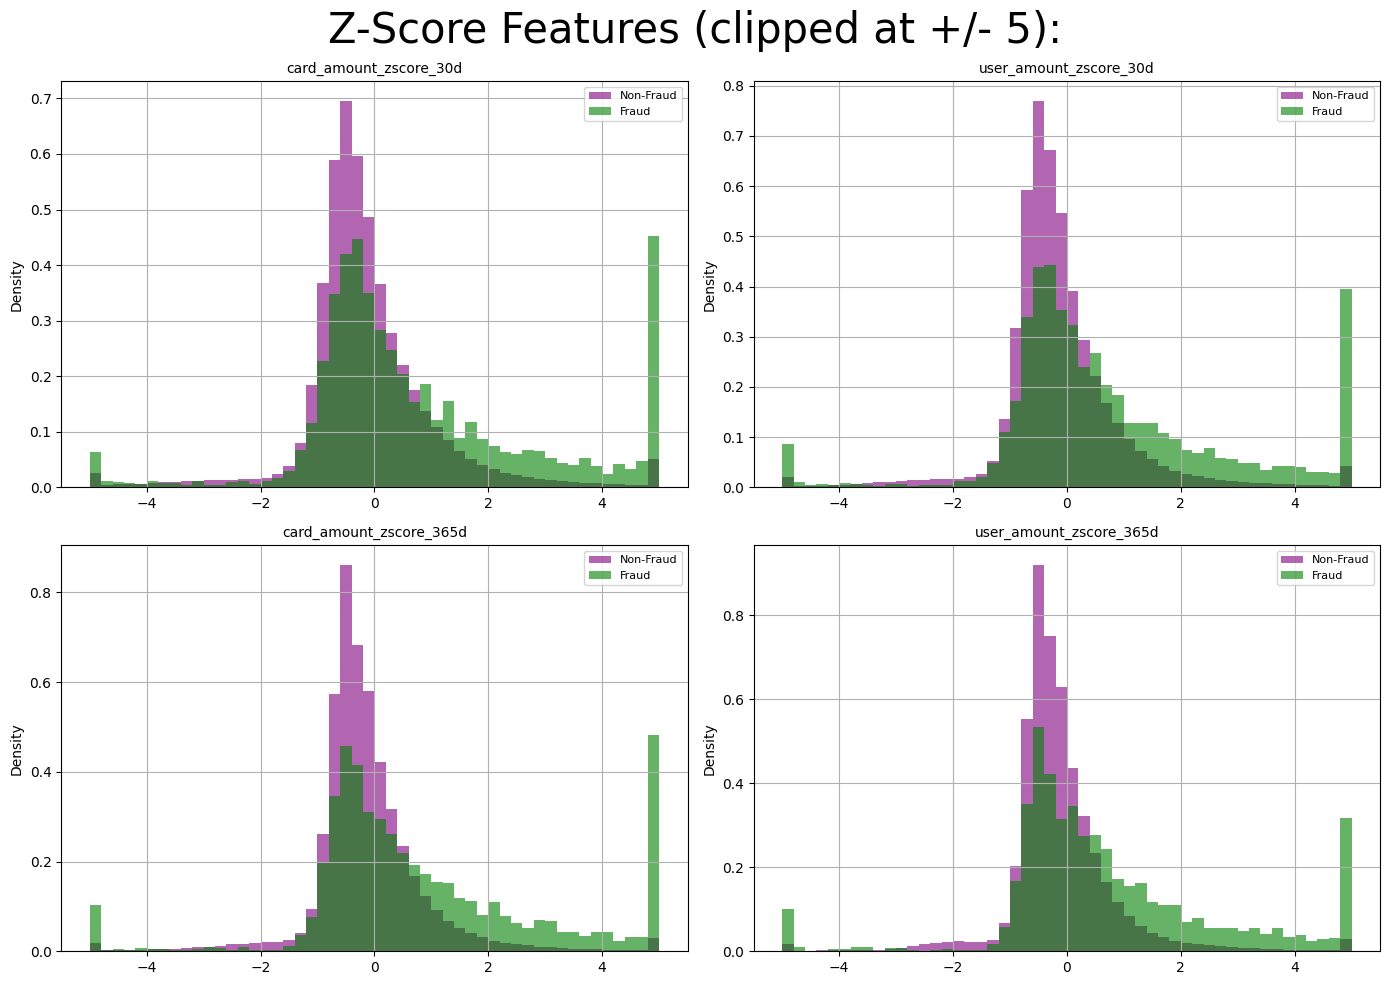

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_01_zscore.png


In [51]:
# Strongest Feature engineered

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Z-Score Features (clipped at +/- 5):", fontsize=30)
axes = axes.flatten()

for i, col in enumerate(zscore_features):
    fraud_avg = fraud[col].mean()
    non_fraud_avg = non_fraud[col].mean()

    fraud_histogram(axes[i], col, col, clip=(-5, 5))

save_and_show(fig, "feature_plot_01_zscore.png")

### Merchant Familiarity

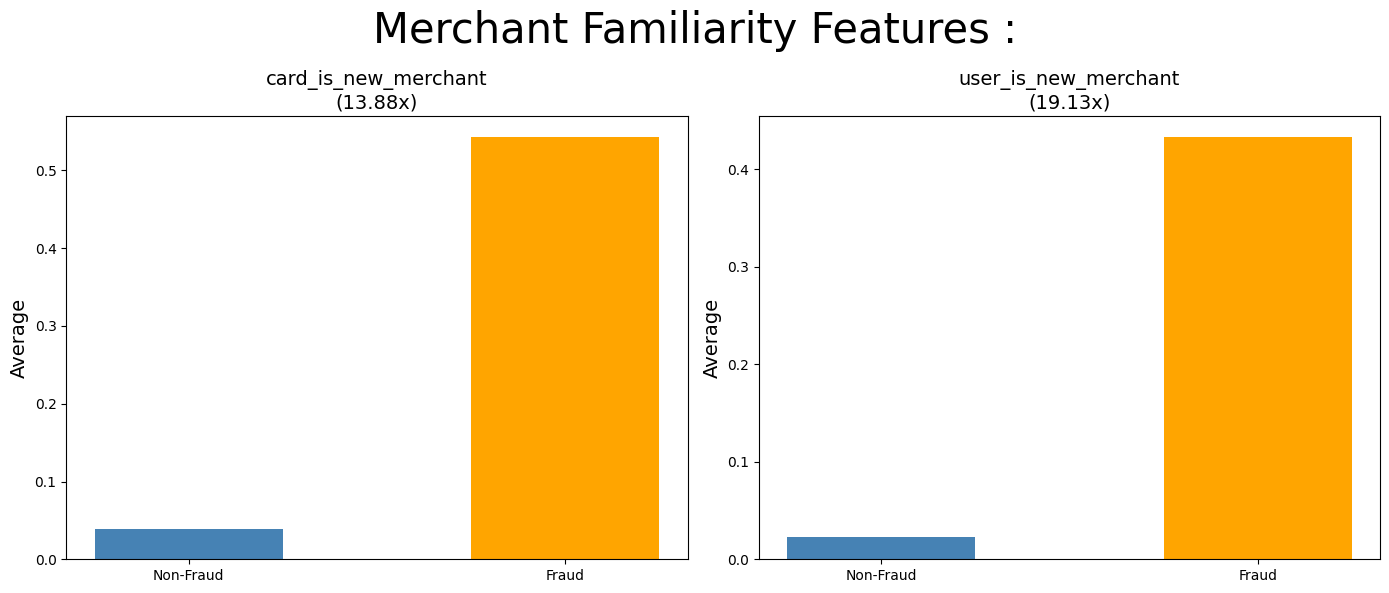

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_02_merchant_familiarity.png


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = np.ravel(axes)

fig.suptitle("Merchant Familiarity Features :", fontsize=30)

for i, col in enumerate(merchant_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_02_merchant_familiarity.png")

### Geographic Features

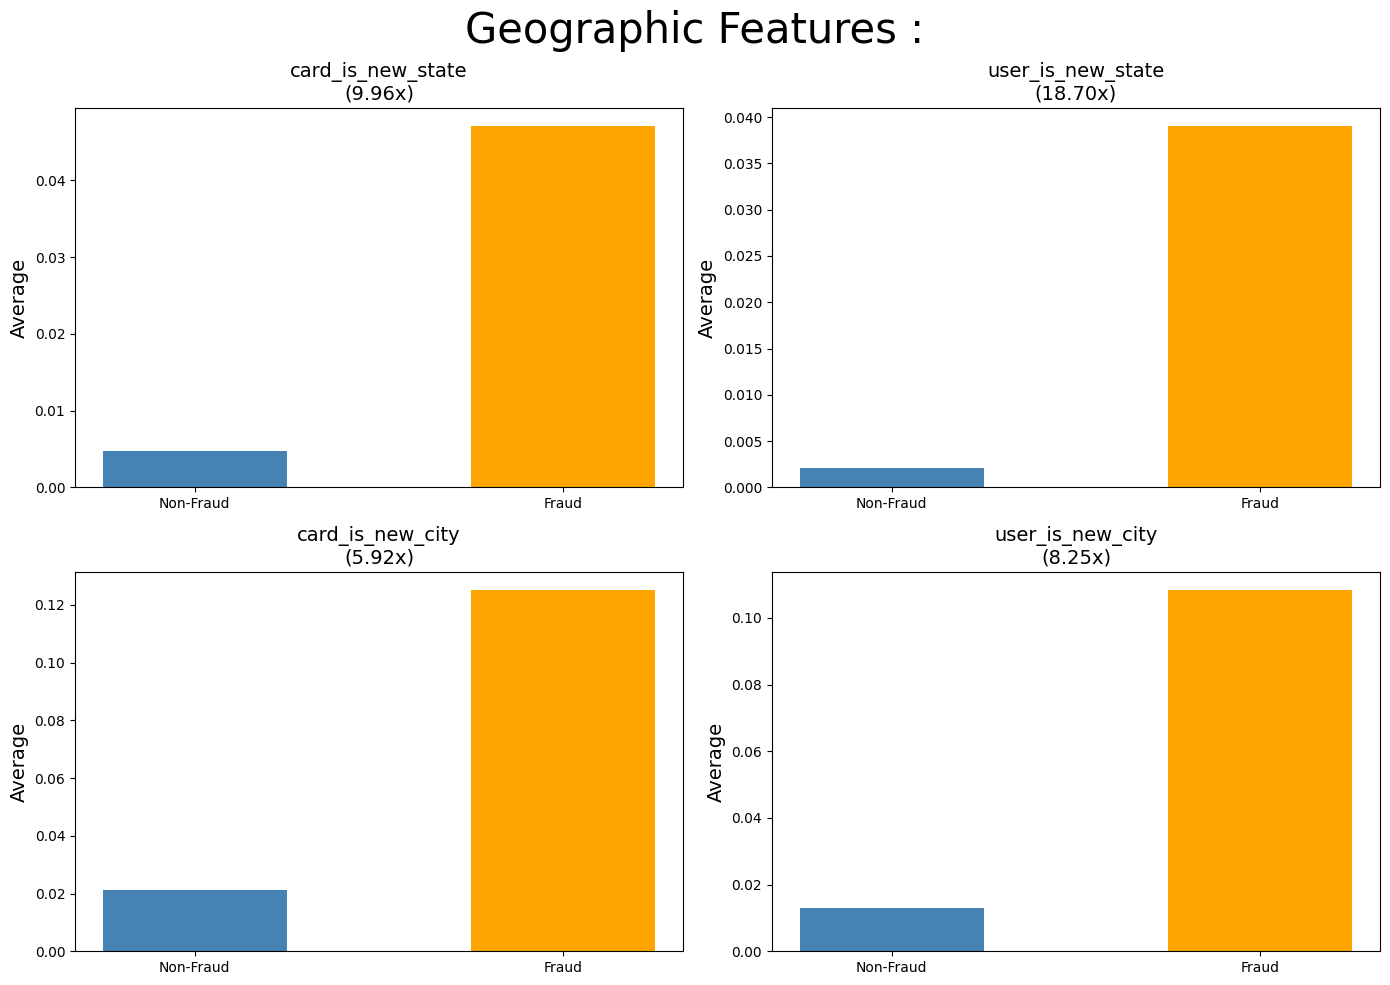

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_03_geographic.png


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.ravel(axes)

fig.suptitle("Geographic Features :", fontsize=30)

for i, col in enumerate(geo_features):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_03_geographic.png")

### Error Features

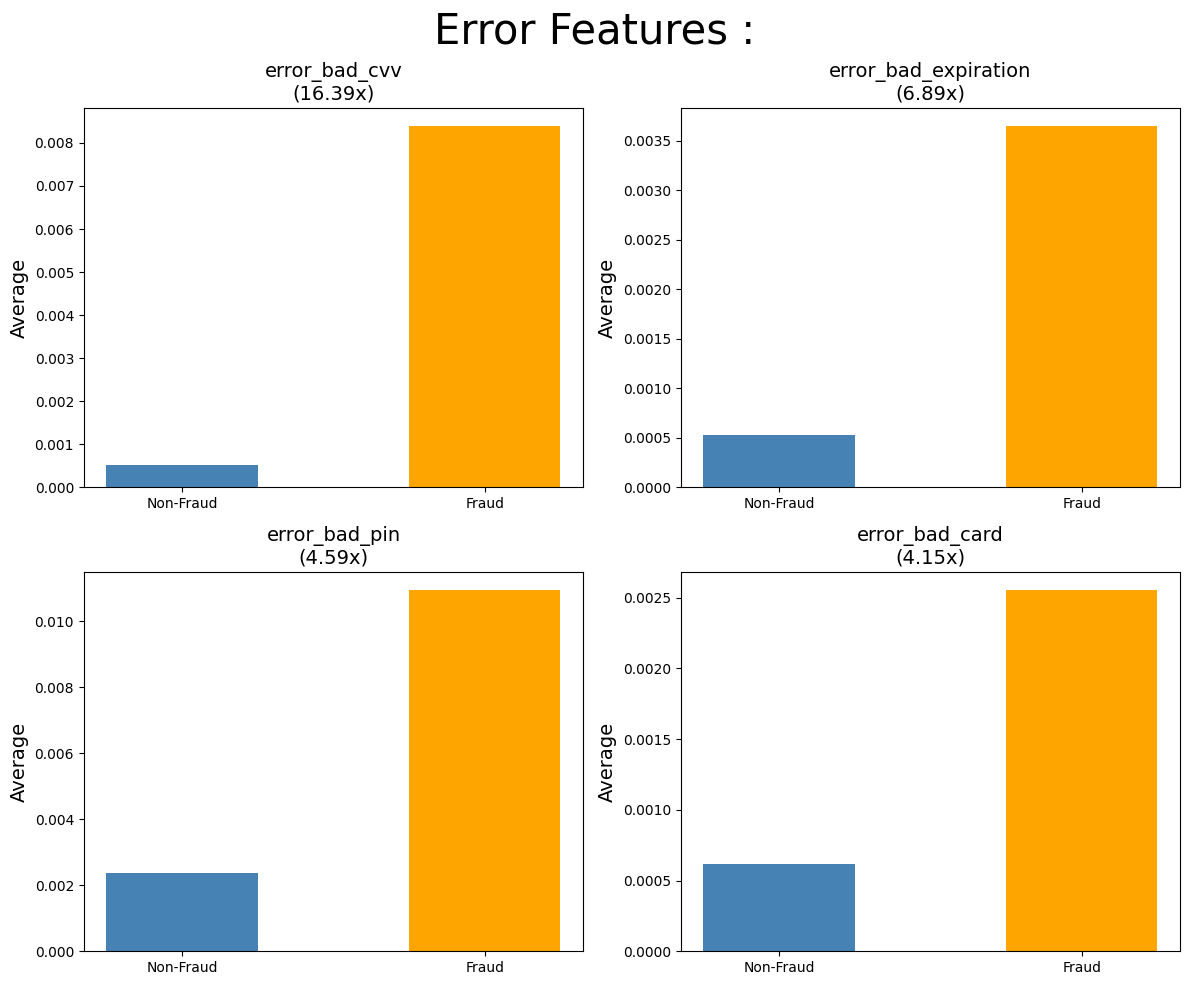

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_04_error.png


In [54]:
error_cols = ["error_bad_cvv", "error_bad_expiration", "error_bad_pin",
              "error_bad_card"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = np.ravel(axes)

fig.suptitle("Error Features :", fontsize=30)

for i, col in enumerate(error_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_04_error.png")

### Raw Features

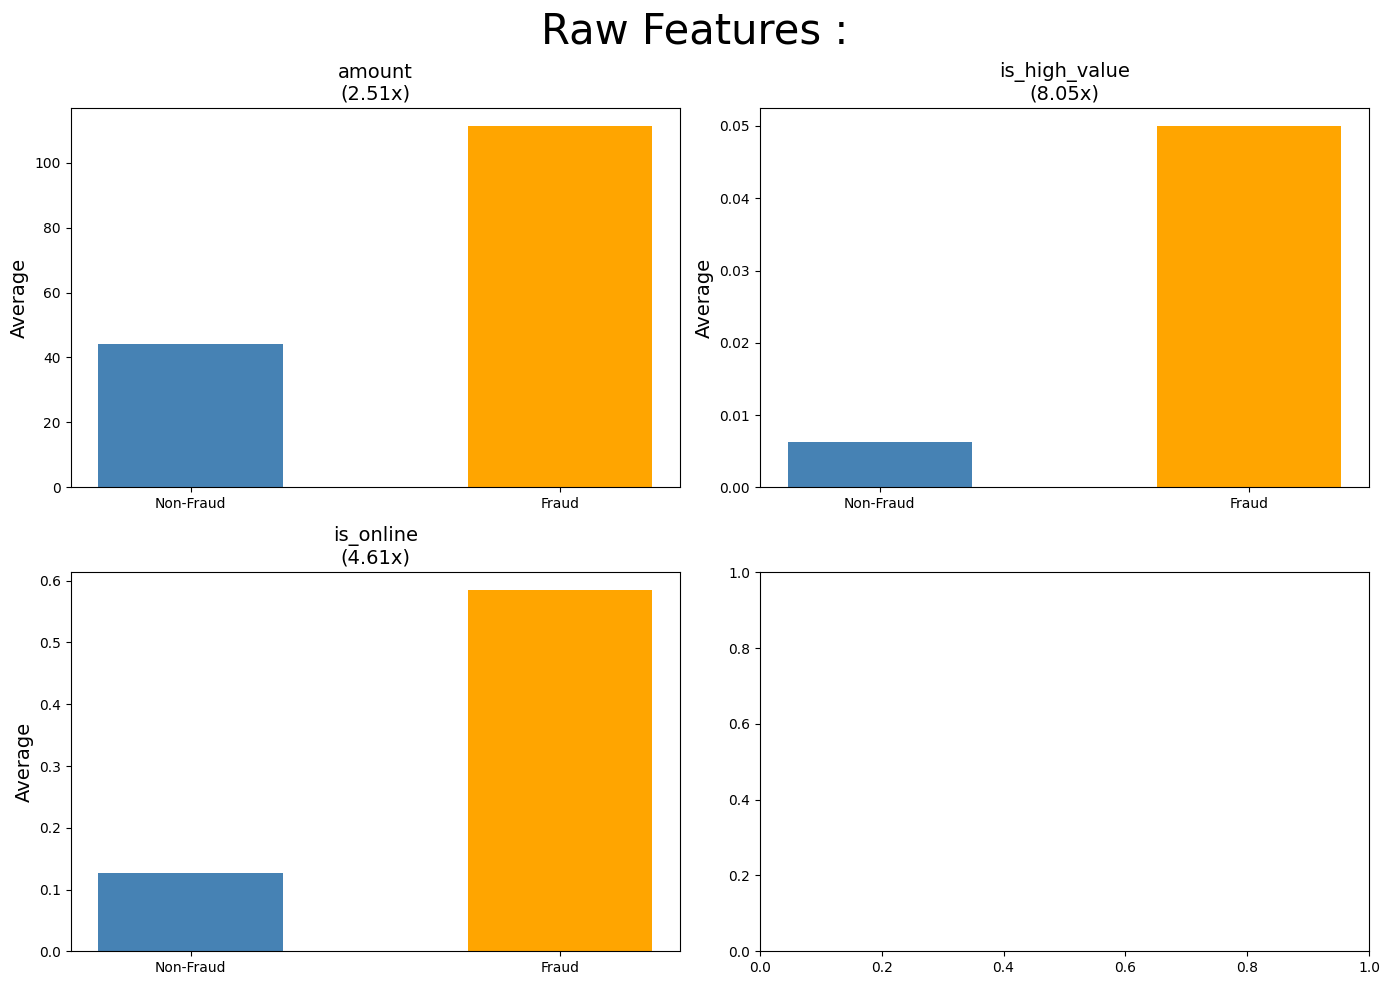

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_05_raw.png


In [55]:
raw_cols = ["amount", "is_high_value", "is_online"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.ravel(axes)

fig.suptitle("Raw Features :", fontsize=30)

for i, col in enumerate(raw_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_05_raw.png")

### Velocity Features

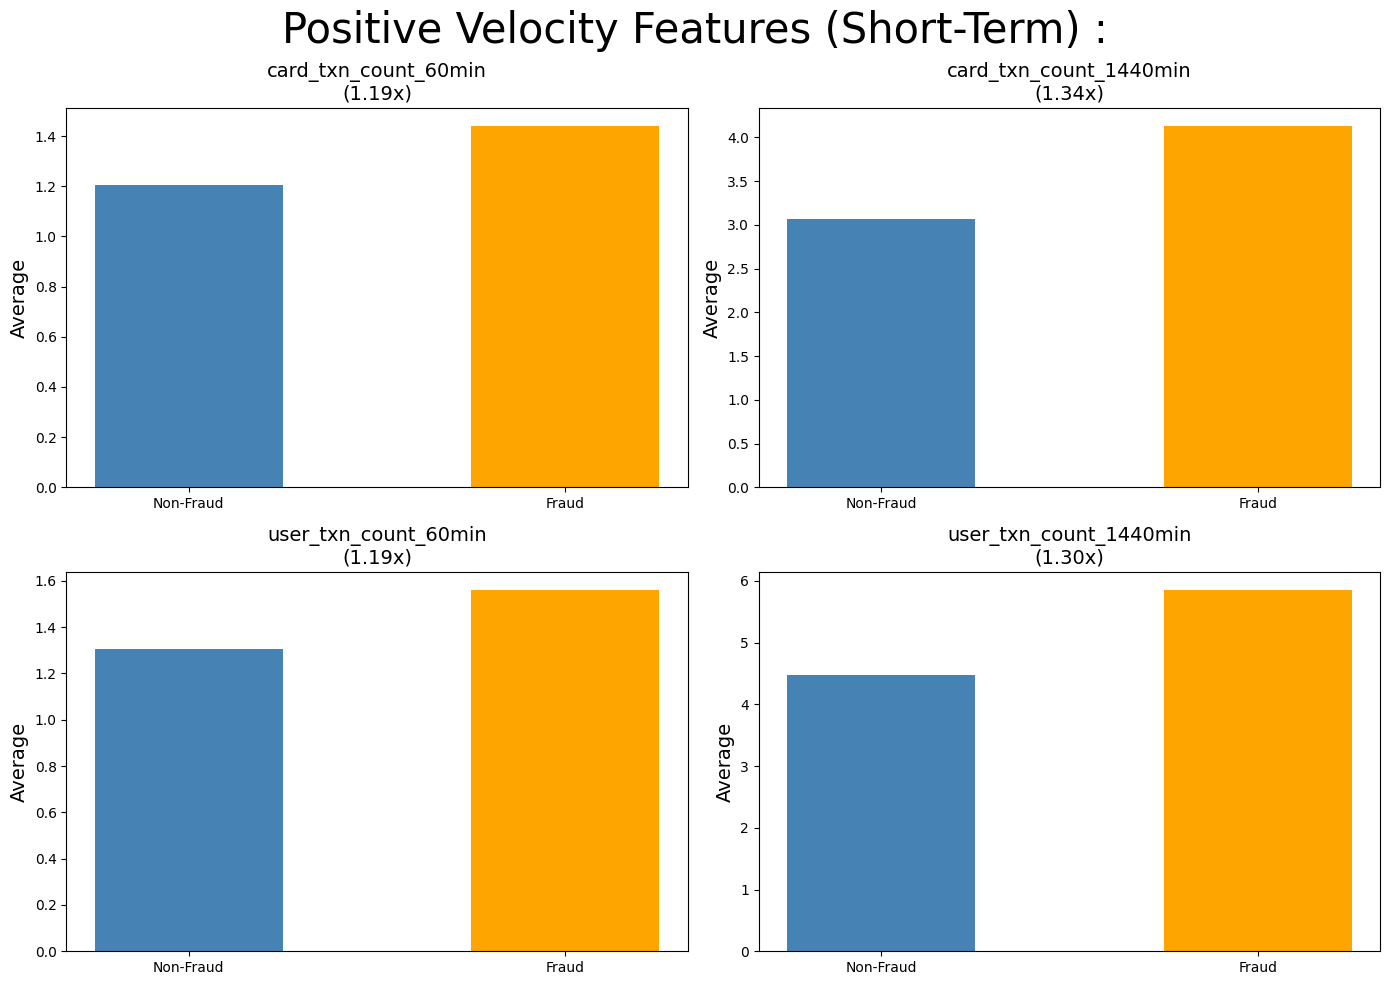

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_06_velocity.png


In [56]:
velocity_cols = ["card_txn_count_60min", "card_txn_count_1440min", "user_txn_count_60min", 
                 "user_txn_count_1440min"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.ravel(axes)

fig.suptitle("Positive Velocity Features (Short-Term) :", fontsize=30)

for i, col in enumerate(velocity_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_06_velocity.png")

### Spend Features

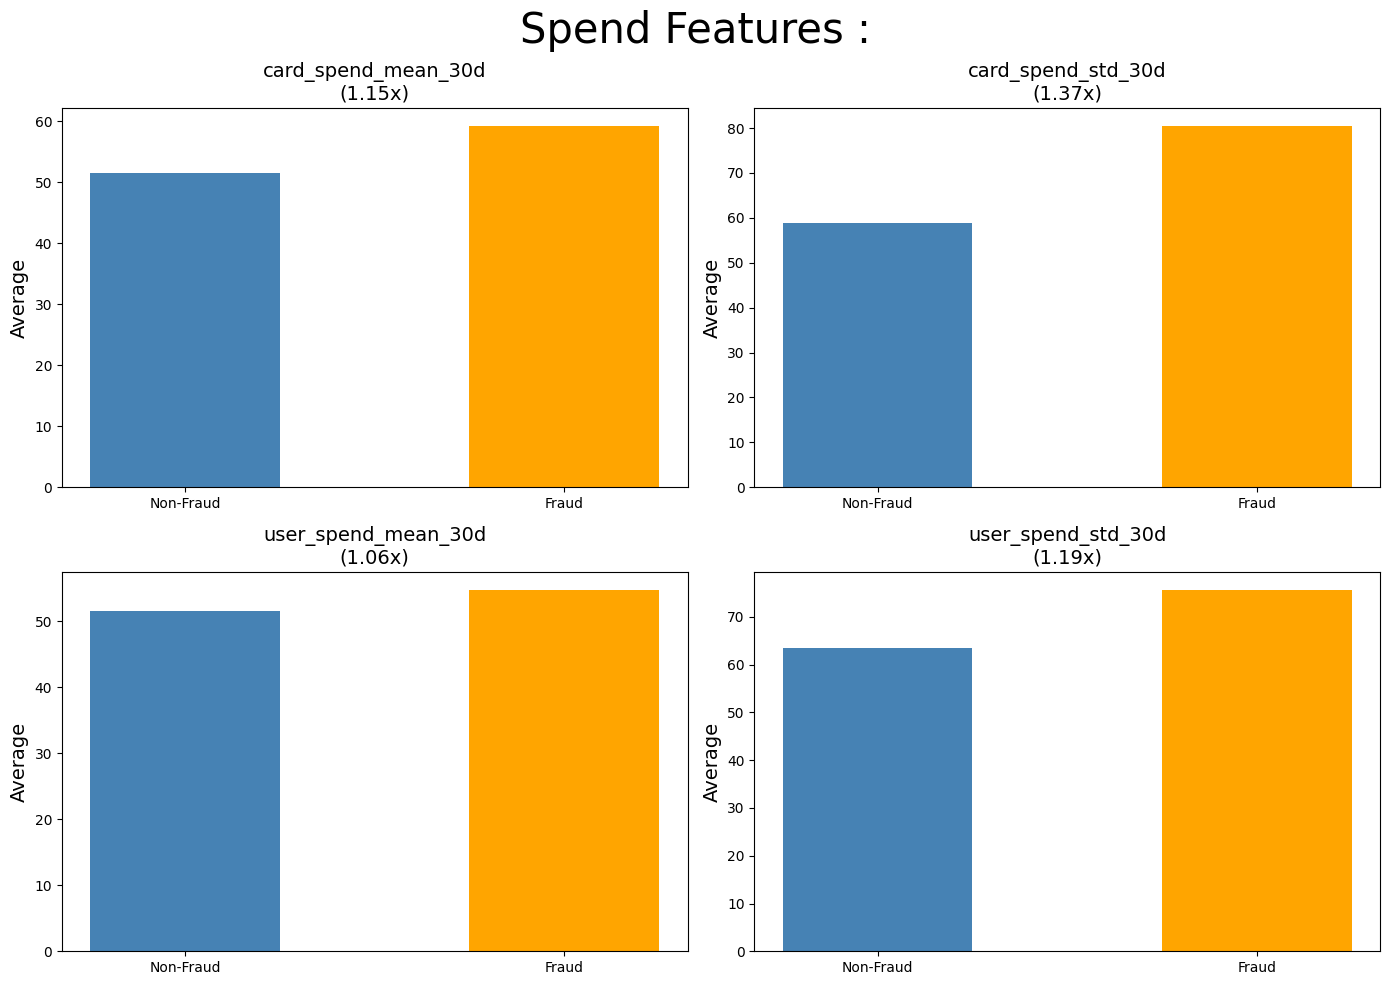

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_07_spend.png


In [57]:
spend_cols = spend_card_cols + spend_user_cols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.ravel(axes)

fig.suptitle("Spend Features :", fontsize=30)

for i, col in enumerate(spend_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_07_spend.png")

### Cross-Card Features

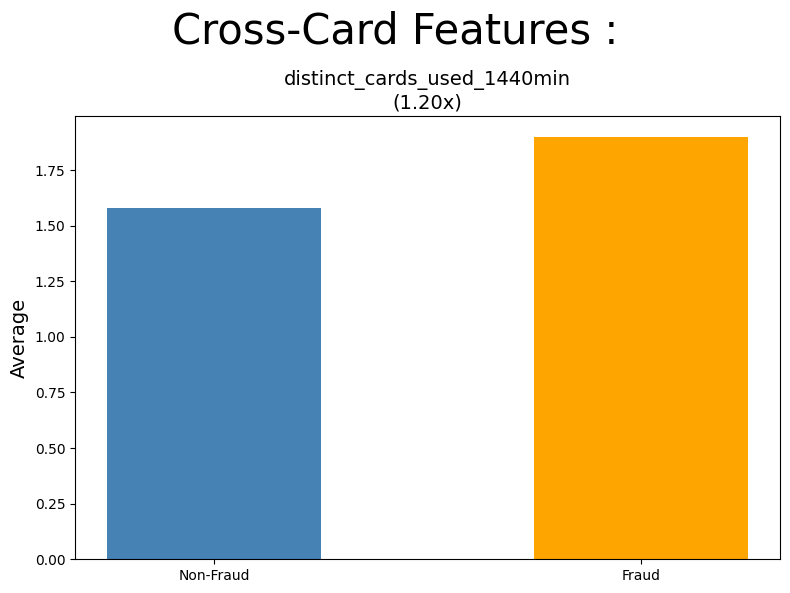

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_08_cross_card.png


In [58]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes = np.ravel(axes)

fig.suptitle("Cross-Card Features :", fontsize=30)

for i, col in enumerate(["distinct_cards_used_1440min"]):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_08_cross_card.png")

### Temporal Features

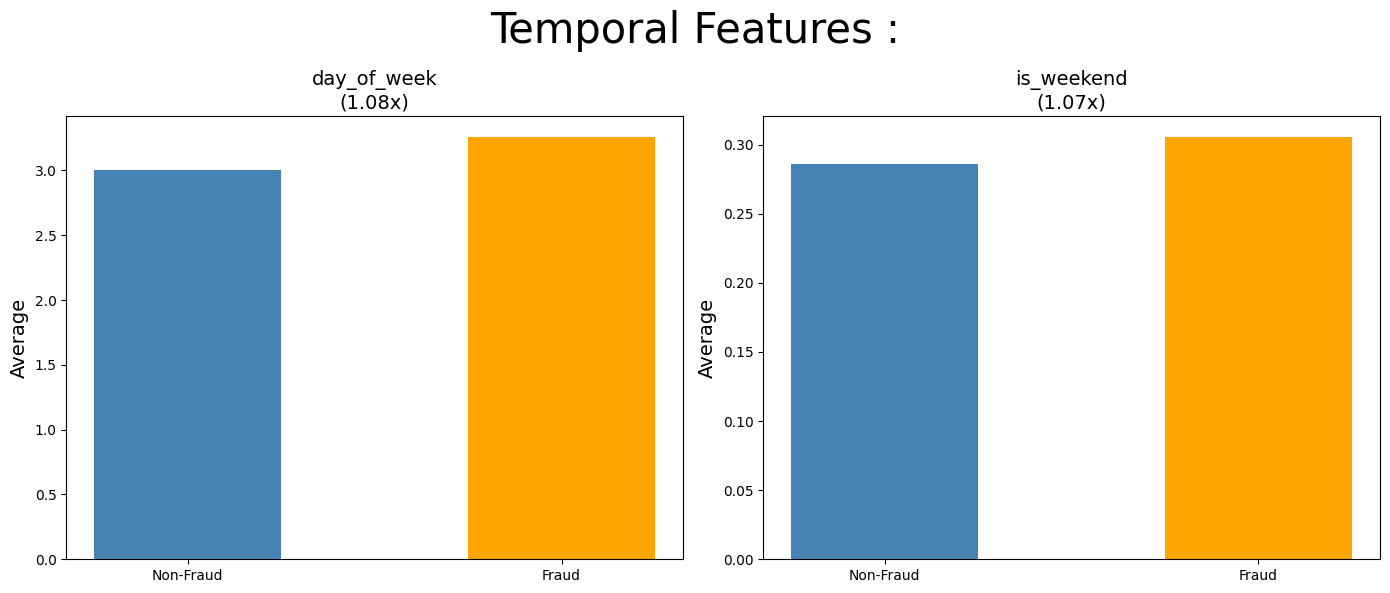

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_09_temporal.png


In [59]:
temp_cols = ["day_of_week", "is_weekend"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = np.ravel(axes)

fig.suptitle("Temporal Features :", fontsize=30)

for i, col in enumerate(temp_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_09_temporal.png")

## Negative Fraud Signals

### Raw and Time Since Last Txn

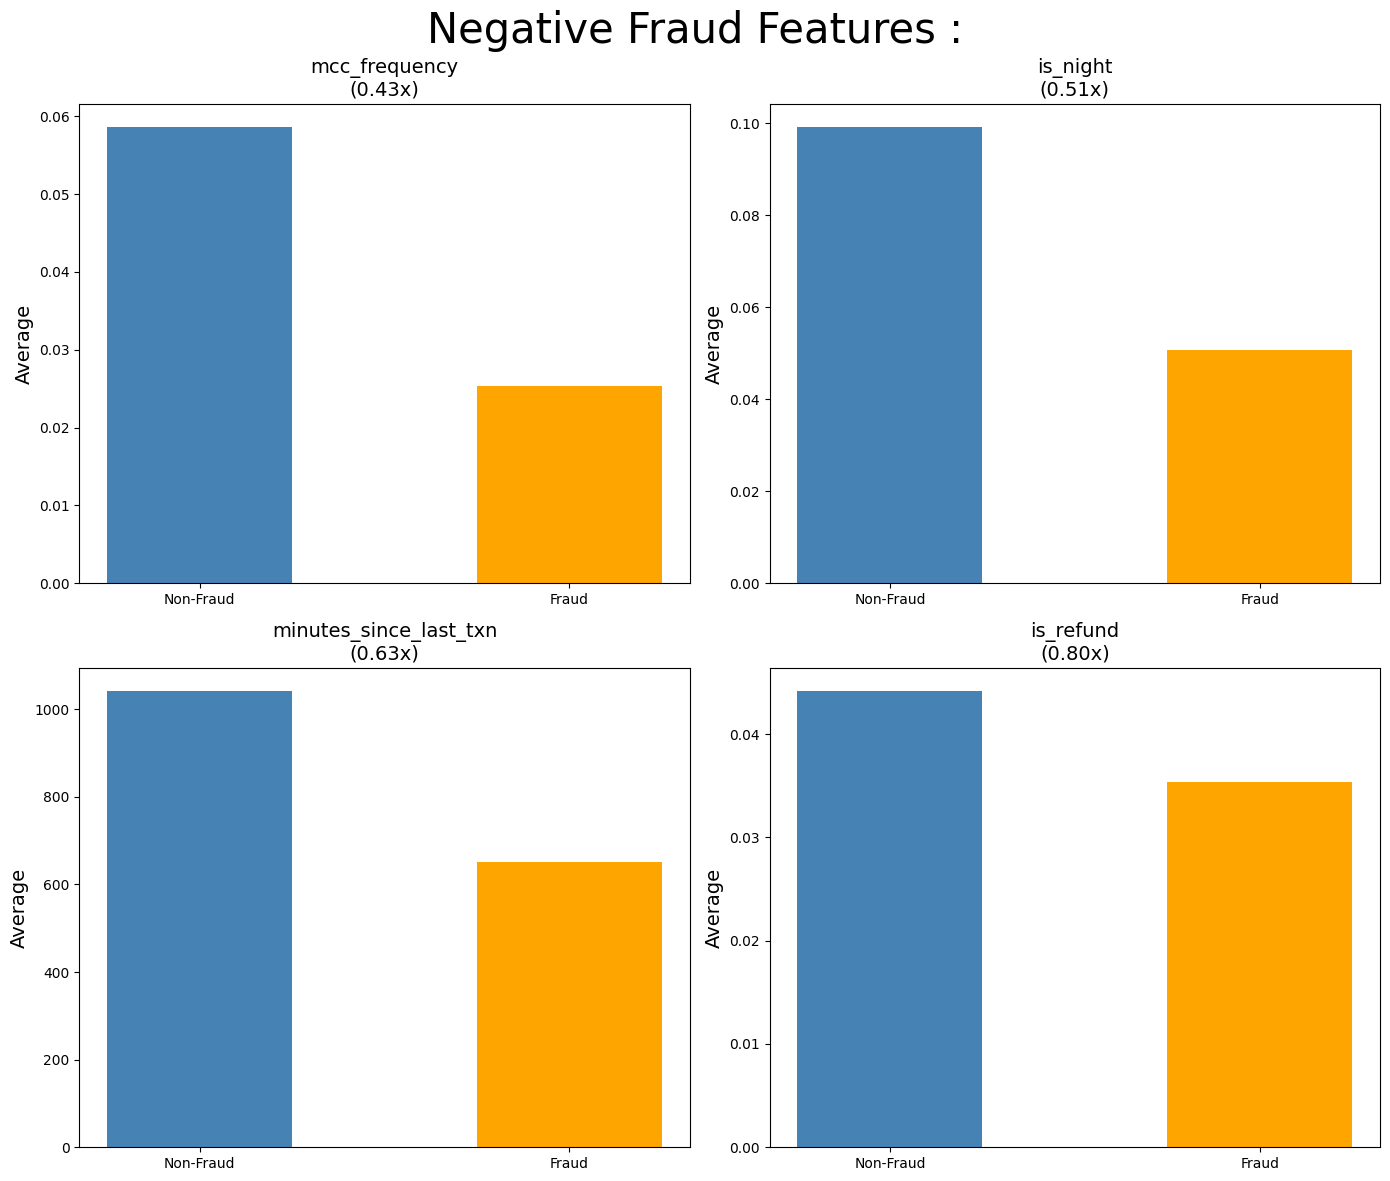

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_10_negative.png


In [60]:
negative_cols = ["mcc_frequency", "is_night", "minutes_since_last_txn", "is_refund"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = np.ravel(axes)

fig.suptitle("Negative Fraud Features :", fontsize=30)

for i, col in enumerate(negative_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_10_negative.png")

### Velocity Features

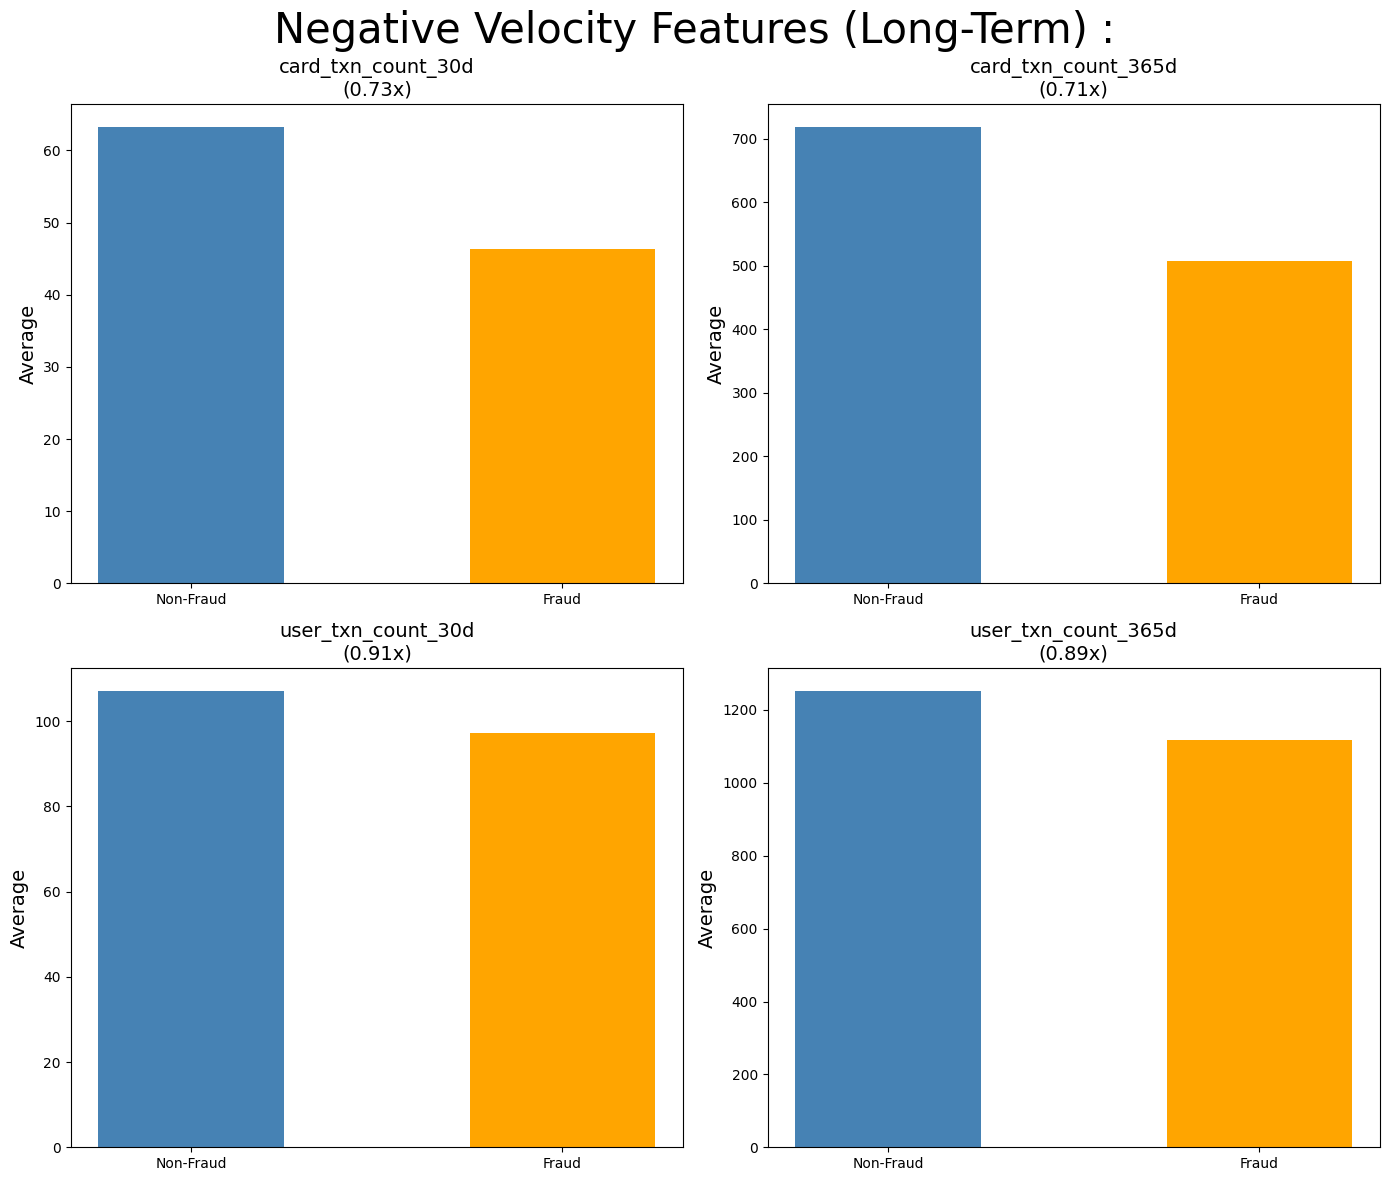

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_11_negative_velocity.png


In [61]:
neg_velocity_cols = ["card_txn_count_30d", "card_txn_count_365d", "user_txn_count_30d", 
                 "user_txn_count_365d"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = np.ravel(axes)

fig.suptitle("Negative Velocity Features (Long-Term) :", fontsize=30)

for i, col in enumerate(neg_velocity_cols):
    fraud_bar_chart(axes[i], col, col, multiplier=get_multiplier(col))

save_and_show(fig, "feature_plot_11_negative_velocity.png")

## Feature Summary

In [62]:
TOP_N = 10

EXCLUDED_FEATURES = {"hour_sin", "hour_cos"}
EXCLUDED_PATTERNS = ["zscore"]

excluded_cols = fraud_signal_table["feature"].isin(EXCLUDED_FEATURES)
for pattern in EXCLUDED_PATTERNS:
    excluded_cols |= fraud_signal_table["feature"].str.contains(pattern, case=False, na=False)

summary_cols = fraud_signal_table[~excluded_cols].copy()

positive_signals = summary_cols.loc[summary_cols["multiplier"] > 1].copy()
negative_signals = summary_cols.loc[summary_cols["multiplier"] <= 1].copy()

top_positive = (
    positive_signals
    .sort_values("multiplier", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

top_negative = (
    negative_signals
    .sort_values("multiplier", ascending=False)
    .reset_index(drop=True)
)

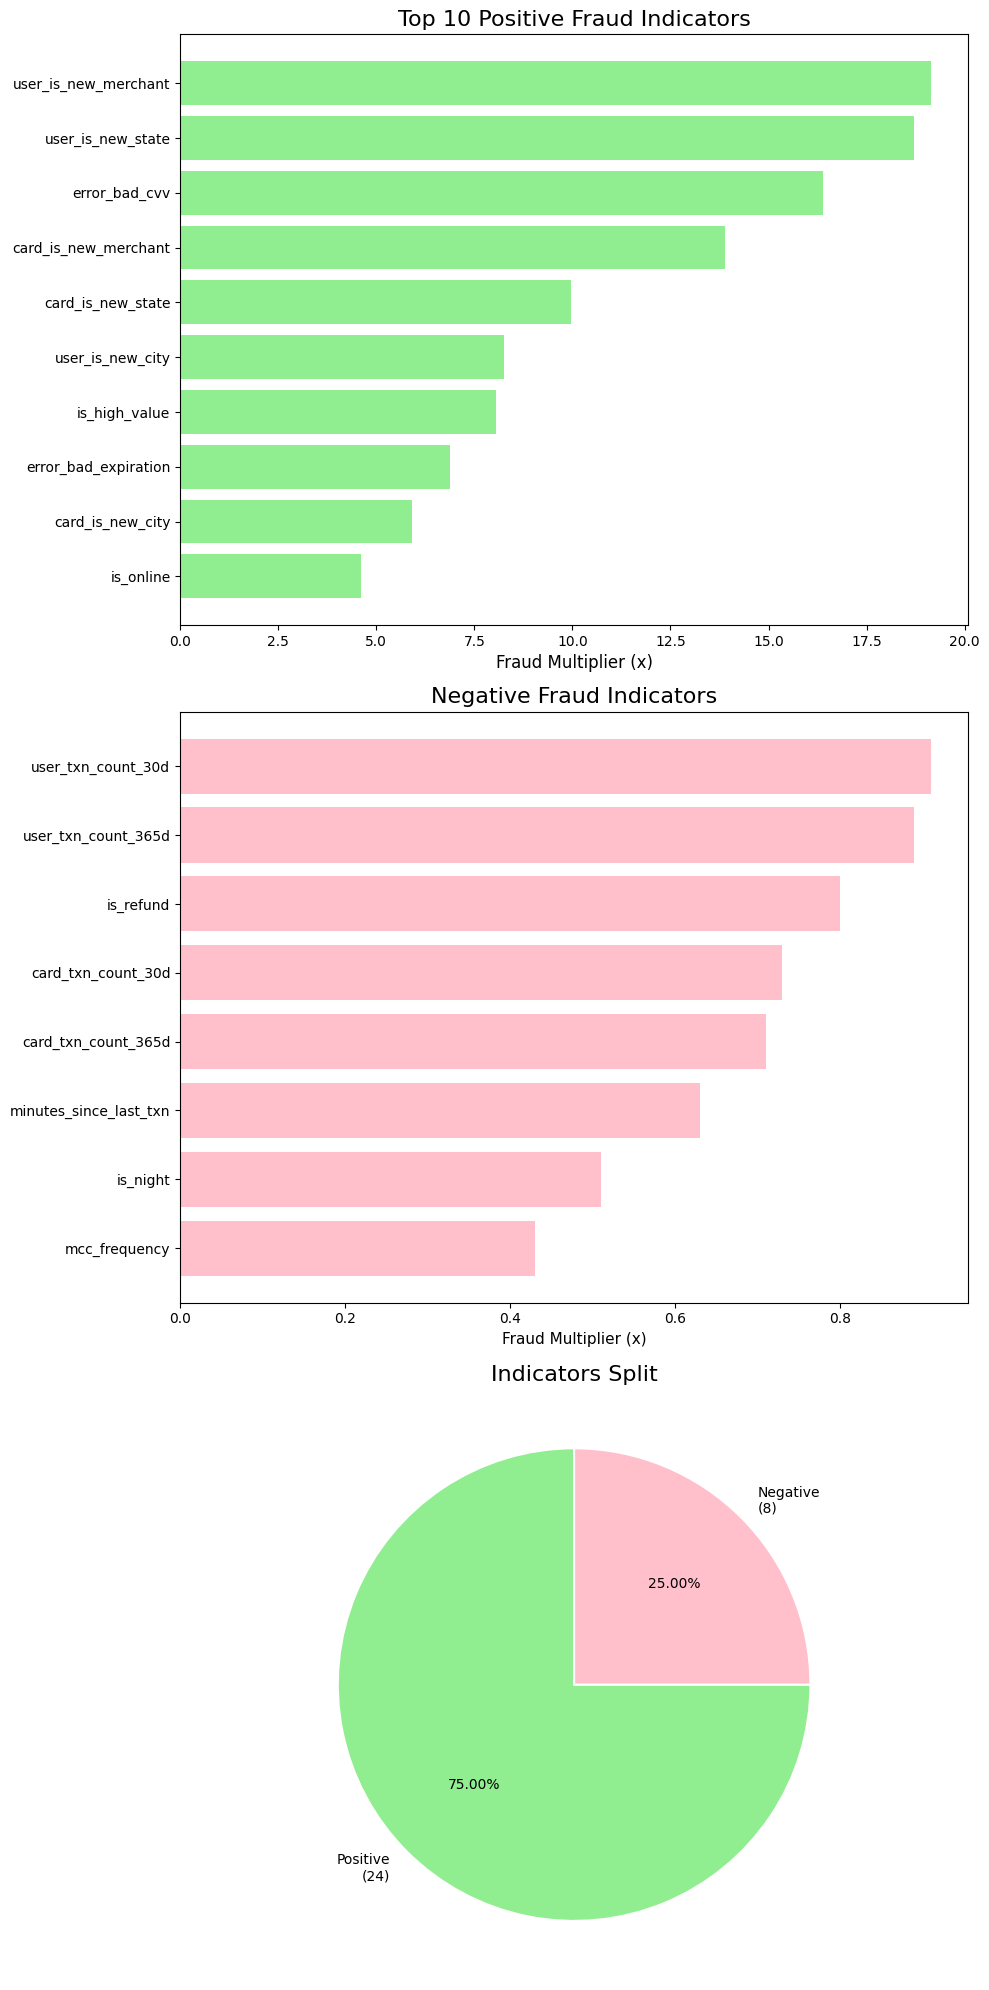

Saved as : C:\Users\HP\Documents\Fraud_Detection_System\notebooks\Feature_plots\feature_plot_12_summary.png


In [63]:
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

# Positive Indicators
ax = axes[0]

ax.barh(top_positive["feature"], top_positive["multiplier"], color="lightgreen")
ax.invert_yaxis()

ax.set_title(f"Top {TOP_N} Positive Fraud Indicators", fontsize=16)
ax.set_xlabel("Fraud Multiplier (x)", fontsize=12)

# Negative Indicators
ax = axes[1]

ax.barh(top_negative["feature"], top_negative["multiplier"], color="pink")
ax.invert_yaxis()

ax.set_title(f"Negative Fraud Indicators", fontsize=16)
ax.set_xlabel("Fraud Multiplier (x)", fontsize=11)

# Indicator Pie Chart
ax = axes[2]

n_pos = len(positive_signals)
n_neg = len(negative_signals)

ax.pie(
    [n_pos, n_neg],
    labels=[f"Positive\n({n_pos})", f"Negative\n({n_neg})"],
    autopct="%1.2f%%",
    colors=["lightgreen", "pink"],
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
    startangle=90
)

ax.set_title("Indicators Split", fontsize=16)

save_and_show(fig, "feature_plot_12_summary.png")